# Online learning with ``braintrace``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/tutorials/braintrace_online_learning.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/tutorials/braintrace_online_learning.ipynb)

## What is `braintrace`?

``braintrace`` is the online-learning package in the BrainX ecosystem. It is designed for recurrent neural networks, spiking neural networks, and other stateful models that process data step by step. Instead of storing the full backpropagation-through-time graph for a long sequence, BrainTrace maintains eligibility traces: compact online summaries of how current hidden states depend on trainable parameters.

This makes BrainTrace useful when a model needs to learn from streaming data, update recurrent parameters during simulation, or study biologically inspired credit-assignment rules. It connects stateful ``brainstate`` modules, ETP-aware primitives, online-learning algorithms such as ``D_RTRL`` and ``EProp``, and JAX transformations in a single workflow.

The architecture below shows the the ``braintrace`` workflow. 
- Define a stateful recurrent or spiking model with hidden states, trainable parameters, and ETP-aware operations.
- Let BrainTrace analyze the model structure and build an eligibility-trace graph that links hidden states, parameters, and operations.
- Choose an online-learning algorithm such as ``D_RTRL`` or ``EProp`` to generate the learner.
- Run the learner on single-step or multi-step data through JAX/XLA, with support for CPU, GPU, and TPU execution.

![BrainTrace architecture for online learning](../_static/image/braintrace_architecture_online_learning.webp)

For the research background, see the Nature Communications article [BrainTrace](https://www.nature.com/articles/s41467-026-68453-w). For complete API details, advanced algorithms, batching, custom primitives, and additional examples, see the [braintrace documentation](https://brainx.chaobrain.com/braintrace/).

This tutorial is a compact entry point rather than a full algorithm reference. It shows how the main pieces fit together:

- build a small recurrent model with ``braintrace.nn`` layers,
- inspect hidden states and ETP-aware operations,
- run a simple streaming update loop,
- compile the model with ``braintrace.compile(..., "D_RTRL", ...)``,
- use ``MultiStepData`` and a small gradient check,
- understand the shape convention used for batching.

## 1. Setup

We use JAX arrays, ``brainstate`` modules and state management, and ``braintrace`` recurrent layers. The examples are intentionally small so that they run quickly during documentation builds.

In [4]:
import jax
import jax.numpy as jnp
import brainstate
import braintrace
import numpy as np
import matplotlib.pyplot as plt

brainstate.random.seed(1)
np.random.seed(1)

## 2. Sequence data for an online task

The toy task uses a two-channel time-varying input and a one-dimensional target. Each time step can be processed immediately, which is the setting where online learning is useful.

inputs shape:  (80, 2)
targets shape: (80, 1)


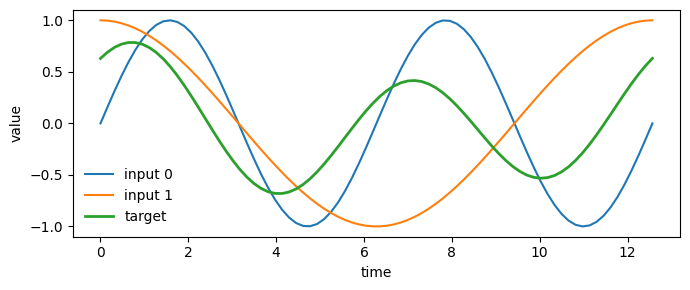

In [5]:
n_steps = 80
time = jnp.linspace(0.0, 4.0 * jnp.pi, n_steps)

inputs = jnp.stack(
    [
        jnp.sin(time),
        jnp.cos(0.5 * time),
    ],
    axis=1,
)
targets = (0.6 * jnp.sin(time + 0.8) + 0.2 * jnp.cos(0.5 * time))[:, None]

print(f"inputs shape:  {inputs.shape}")
print(f"targets shape: {targets.shape}")

plt.figure(figsize=(7, 3))
plt.plot(np.asarray(time), np.asarray(inputs[:, 0]), label="input 0")
plt.plot(np.asarray(time), np.asarray(inputs[:, 1]), label="input 1")
plt.plot(np.asarray(time), np.asarray(targets[:, 0]), label="target", linewidth=2)
plt.xlabel("time")
plt.ylabel("value")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. A small recurrent model

``braintrace.nn`` layers are regular ``brainstate`` modules whose internal matrix operations are marked with BrainTrace ETP primitives. Here we start with a recurrent encoder and inspect the hidden state produced by one update.

In [6]:
class TinyRecurrentEncoder(brainstate.nn.Module):
    def __init__(self, n_in, n_hidden):
        super().__init__()
        self.rnn = braintrace.nn.ValinaRNNCell(
            n_in,
            n_hidden,
            activation="tanh",
            w_init=0.08 * brainstate.random.randn(n_in + n_hidden, n_hidden),
        )

    def update(self, x):
        return self.rnn(x)


encoder = TinyRecurrentEncoder(n_in=2, n_hidden=8)
brainstate.nn.init_all_states(encoder)

h0 = encoder(inputs[0])

print(f"hidden state shape: {encoder.rnn.h.value.shape}")
print(f"single-step output shape: {h0.shape}")
print(f"hidden-state norm after one step: {float(jnp.linalg.norm(h0)):.4f}")

hidden state shape: (8,)
single-step output shape: (8,)
hidden-state norm after one step: 0.2684


## 4. A step-by-step online loop

This cell shows the streaming data flow before introducing the BrainTrace compiler. The recurrent encoder carries its hidden state forward, and a simple readout is updated immediately from the current prediction error.

The readout update below is intentionally written out by hand so the online-learning loop is visible. The later BrainTrace cells show how ``D_RTRL`` compiles recurrent dependencies and routes gradients through eligibility traces.

output trajectory shape: (80,)
mean loss, first 10 steps: 0.2488
mean loss, last 10 steps:  0.1734
final readout weight norm: 0.2302


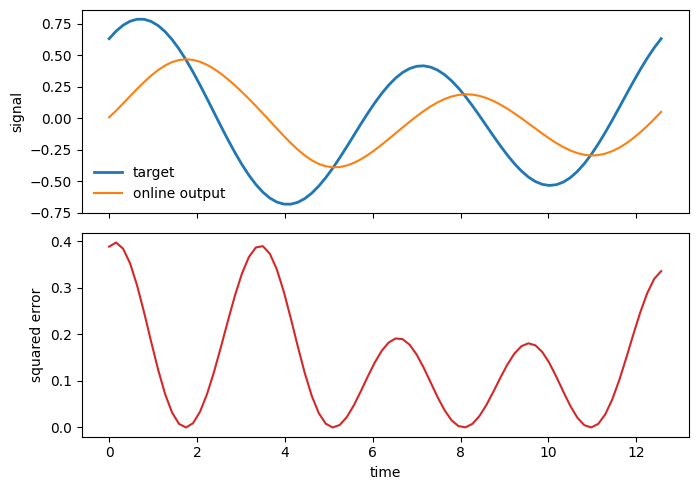

In [7]:
brainstate.random.seed(2)
encoder = TinyRecurrentEncoder(n_in=2, n_hidden=8)
brainstate.nn.init_all_states(encoder)

w_readout = 0.05 * brainstate.random.randn(8, 1)
b_readout = jnp.zeros((1,))
learning_rate = 0.08

outputs = []
losses = []
hidden_norms = []

for x_t, y_t in zip(inputs, targets):
    h_t = encoder(x_t)
    y_hat = h_t @ w_readout + b_readout
    error = y_hat - y_t

    # Immediate online update for the readout parameters.
    w_readout = w_readout - learning_rate * h_t[:, None] * error
    b_readout = b_readout - learning_rate * error

    outputs.append(y_hat.squeeze())
    losses.append(jnp.mean(error ** 2))
    hidden_norms.append(jnp.linalg.norm(h_t))

outputs = jnp.asarray(outputs)
losses = jnp.asarray(losses)
hidden_norms = jnp.asarray(hidden_norms)

print(f"output trajectory shape: {outputs.shape}")
print(f"mean loss, first 10 steps: {float(jnp.mean(losses[:10])):.4f}")
print(f"mean loss, last 10 steps:  {float(jnp.mean(losses[-10:])):.4f}")
print(f"final readout weight norm: {float(jnp.linalg.norm(w_readout)):.4f}")

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(np.asarray(time), np.asarray(targets[:, 0]), label="target", linewidth=2)
axes[0].plot(np.asarray(time), np.asarray(outputs), label="online output")
axes[0].set_ylabel("signal")
axes[0].legend(frameon=False)
axes[1].plot(np.asarray(time), np.asarray(losses), color="tab:red")
axes[1].set_ylabel("squared error")
axes[1].set_xlabel("time")
plt.tight_layout()
plt.show()

## 5. ETP-aware operations and hidden states

BrainTrace decides which parameters participate in eligibility-trace computation from the operations used in the model. For example, ``braintrace.nn.Linear`` calls ``braintrace.matmul`` internally, so its weight is visible to the ETP compiler. Regular JAX operations can still be used for computations that should not be part of the ETP graph.

In [8]:
x_example = jnp.array([1.0, -0.5])
w_example = jnp.array(
    [
        [0.2, -0.1, 0.4],
        [0.3, 0.5, -0.2],
    ]
)

marked_output = braintrace.matmul(x_example, w_example)
plain_output = x_example @ w_example

print(f"braintrace.matmul output: {marked_output}")
print(f"plain JAX matmul output:  {plain_output}")
print(f"same numerical result:    {bool(jnp.allclose(marked_output, plain_output))}")

braintrace.matmul output: [ 0.05 -0.35  0.5 ]
plain JAX matmul output:  [ 0.05 -0.35  0.5 ]
same numerical result:    True


## 6. Compile an eligibility-trace graph

The online-learning algorithms wrap a model and compile its hidden-state/parameter/primitive relationships. ``braintrace.compile`` is the convenient entry point: it constructs the requested learner, forwards options such as ``vjp_method``, and eagerly builds the eligibility-trace graph from an example input.

In this example the recurrent cell is ETP-aware, while the output head is a plain ``brainstate.ParamState`` applied with standard JAX matrix multiplication. This keeps the compiled trace focused on the recurrent hidden-state dependency. Use ``braintrace.nn`` layers or explicit ETP primitives when a feedforward parameter should also be part of the ETP graph.

In [9]:
class TinyRNNReadout(brainstate.nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.rnn = braintrace.nn.ValinaRNNCell(
            n_in,
            n_hidden,
            activation="tanh",
            w_init=0.08 * brainstate.random.randn(n_in + n_hidden, n_hidden),
        )
        self.out = brainstate.ParamState(
            {
                "weight": 0.1 * brainstate.random.randn(n_hidden, n_out),
                "bias": jnp.zeros((n_out,)),
            }
        )

    def update(self, x):
        h = self.rnn(x)
        out = self.out.value
        return h @ out["weight"] + out["bias"]


brainstate.random.seed(3)
etp_model = TinyRNNReadout(n_in=2, n_hidden=6, n_out=1)
brainstate.nn.init_all_states(etp_model)

learner = braintrace.compile(
    etp_model,
    "D_RTRL",
    inputs[0],
    vjp_method="multi-step",
)

graph = learner.graph_executor.graph
parameter_keys = list(etp_model.states(brainstate.ParamState).keys())

print(f"learner compiled: {learner.is_compiled}")
print(f"compiled graph type: {type(graph).__name__}")
print(f"hidden groups: {len(graph.hidden_groups)}")
print(f"hidden-parameter-op relations: {len(graph.hidden_param_op_relations)}")
print(f"parameter keys: {parameter_keys}")

learner compiled: True
compiled graph type: ETraceGraph
hidden groups: 1
hidden-parameter-op relations: 1
parameter keys: [('out',), ('rnn', 'W', 'weight')]


## 7. Multi-step data and online gradients

``MultiStepData`` marks an input array whose leading axis is time. The learner can then process a full sequence while updating model states and eligibility traces internally.

BrainTrace learners are stateful: each call advances hidden states and trace states. For a clean gradient example, the helper below constructs a fresh model and learner inside the loss function. In a real training loop, gradients from this pattern would be passed to an optimizer.

In [10]:
short_inputs = inputs[:30]
short_targets = targets[:30]


def make_compiled_learner(seed=4):
    brainstate.random.seed(seed)
    model = TinyRNNReadout(n_in=2, n_hidden=6, n_out=1)
    brainstate.nn.init_all_states(model)
    learner = braintrace.compile(
        model,
        "D_RTRL",
        short_inputs[0],
        vjp_method="multi-step",
    )
    return model, learner


model_for_forward, learner_for_forward = make_compiled_learner(seed=4)
sequence_outputs = learner_for_forward(braintrace.MultiStepData(short_inputs))
sequence_loss_value = jnp.mean((sequence_outputs - short_targets) ** 2)

model_for_grad, learner_for_grad = make_compiled_learner(seed=4)
params = model_for_grad.states(brainstate.ParamState)


def sequence_loss(seq):
    y = learner_for_grad(braintrace.MultiStepData(seq))
    return jnp.mean((y - short_targets) ** 2)


grads = brainstate.transform.grad(sequence_loss, params)(short_inputs)

grad_norms = {}
for key, grad_tree in grads.items():
    leaves = jax.tree_util.tree_leaves(grad_tree)
    grad_norms[key] = sum(float(jnp.linalg.norm(leaf)) for leaf in leaves)

print(f"sequence output shape: {sequence_outputs.shape}")
print(f"sequence loss: {float(sequence_loss_value):.4f}")
for key, norm in grad_norms.items():
    print(f"gradient norm for {key}: {norm:.4f}")

sequence output shape: (30, 1)
sequence loss: 0.3298
gradient norm for ('out',): 0.1781
gradient norm for ('rnn', 'W', 'weight'): 0.1525


## 8. Single-step, multi-step, and batching notes

Use ``SingleStepData`` for values that belong to the current time step and ``MultiStepData`` for arrays with a leading time dimension.

For stateful model batching, the full BrainTrace documentation recommends compiling the model for a single sample and creating independent per-sample states with ``brainstate.transform.vmap_new_states`` or ``brainstate.nn.Vmap``. The lightweight example below only applies ordinary JAX ``vmap`` to a stateless summary function, so the batch/time shape convention is clear without adding more state-management code.

In [11]:
single_step = braintrace.SingleStepData(inputs[0])
multi_step = braintrace.MultiStepData(inputs[:5])

batch_inputs = jnp.stack(
    [
        inputs,
        inputs * jnp.array([0.5, 1.2]),
        inputs * jnp.array([1.2, 0.7]),
    ],
    axis=0,
)


def sequence_energy(seq):
    return jnp.mean(seq ** 2)


batch_energy = jax.vmap(sequence_energy)(batch_inputs)

print(f"SingleStepData shape: {single_step.data.shape}")
print(f"MultiStepData shape:  {multi_step.data.shape}")
print(f"batched sequence shape: {batch_inputs.shape}")
print(f"per-sample sequence energy: {batch_energy}")

SingleStepData shape: (2,)
MultiStepData shape:  (5, 2)
batched sequence shape: (3, 80, 2)
per-sample sequence energy: [0.5        0.4262188  0.47953126]


## 9. Choosing an algorithm

BrainTrace provides several online-learning algorithms. For this overview, it is enough to know the common entry points:

| Algorithm | Typical use |
| --- | --- |
| ``D_RTRL`` | General RNN-style online gradients with diagonal RTRL approximation. |
| ``ES_D_RTRL`` / ``pp_prop`` | Larger models where an input-output factorized trace is preferred. |
| ``EProp`` | Spiking or recurrent models using eligibility propagation style learning signals. |
| ``OSTLRecurrent`` / ``OSTLFeedforward`` | Online spatial/temporal learning variants for specific recurrent or feedforward settings. |

The exact choice depends on model structure, memory budget, and the approximation you want. The full [braintrace documentation](https://brainx.chaobrain.com/braintrace/) gives algorithm-level details and SNN examples.

## 10. Practical checks

When adapting this pattern to a larger model, check the following before running long jobs:

| Check | Why it matters |
| --- | --- |
| ``braintrace.compile(model, "D_RTRL", example_input, ...)`` succeeds | The compiler must see the hidden states, parameters, and ETP primitives. |
| Hidden-state shapes match single-step input shapes | Shape mismatches often come from mixing batched and unbatched states. |
| The expected parameters appear in ``model.states(brainstate.ParamState)`` | Only parameters stored as states can be differentiated or optimized. |
| ETP-aware operations are used where trace relationships are needed | Ordinary JAX operations are fine for non-recurrent output heads or other parameters outside the ETP graph. |
| ``MultiStepData`` uses a leading time axis | BrainTrace treats the first axis as time for multi-step inputs. |
| Use fresh learners for independent gradient checks | Learners carry hidden states and eligibility traces across calls. |
| Control flow inside ``update()`` is simple | Keep ``jax.lax.scan``, nested ``vmap``, and complex conditionals outside the model update when compiling BrainTrace graphs. |

For deeper coverage, see the BrainTrace pages on [core concepts](https://brainx.chaobrain.com/braintrace/quickstart/concepts.html), [RNN online learning](https://brainx.chaobrain.com/braintrace/quickstart/rnn_online_learning.html), [ETP primitives](https://brainx.chaobrain.com/braintrace/tutorials/etp_primitives.html), and [batching](https://brainx.chaobrain.com/braintrace/tutorials/batching.html).

## 11. Summary

``braintrace`` adds online-learning machinery around ordinary BrainX/JAX model code. The workflow is:

1. define recurrent state with ``brainstate`` modules,
2. use ``braintrace.nn`` layers or ETP primitives for trainable operations that should participate in eligibility traces,
3. keep ordinary ``ParamState`` and JAX operations for model parts that do not need ETP trace relationships,
4. initialize states and call ``braintrace.compile`` with an example single-step input,
5. run single-step or ``MultiStepData`` inputs through a learner such as ``D_RTRL``,
6. combine the learner with gradients, optimizers, batching, and visualization as needed.

This notebook is a compact overview for the BrainX tutorial collection. For full algorithms, SNN examples, graph visualization, custom primitives, and limitations, use the complete [braintrace documentation](https://brainx.chaobrain.com/braintrace/).